### Imports

In [45]:
import pandas as pd 
import numpy as np
from sqlalchemy import create_engine
import pymysql
from urllib.parse import quote_plus
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, RobustScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor)
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)
from lightgbm import LGBMRegressor

from sklearn.model_selection import RandomizedSearchCV


### DataBase Connection

In [2]:
username = "root"
password = "6241423roya"

host = "localhost"
port = 3306
database = "super_store"

encoded_password = quote_plus(password)

engine = create_engine(
    f"mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}")

In [3]:
# connection test 
connection = engine.connect()

print("Connection successful!")

Connection successful!


In [4]:
connection.close()

In [5]:
query = """
    SELECT
    f.OrderID,
    f.OrderDate,
    f.ShipDate,
    f.Sales,
    f.Quantity,
    f.Discount,

    g.City,
    g.Country,
    g.Market,
    g.Region,
    g.State,

    op.OrderPriority,

    c.Segment,

    p.Category,
    p.SubCategory,
    p.ProductName,

    sm.ShipMode,

    f.Profit

FROM factsales AS f

LEFT JOIN dimgeography AS g
    ON f.GeoKey = g.GeoKey

LEFT JOIN dimorderpriority AS op
    ON f.PriorityKey = op.PriorityKey

LEFT JOIN dimcustomer AS c
    ON f.CustomerID = c.CustomerID

LEFT JOIN dimproduct AS p
    ON f.ProductID = p.ProductID

LEFT JOIN dimshipmode AS sm
    ON f.ShipModeID = sm.ShipModeID;
    """

In [6]:
df = pd.read_sql(query, engine)

In [7]:
df.head()

,OrderID,OrderDate,ShipDate,Sales,Quantity,Discount,City,Country,Market,Region,State,OrderPriority,Segment,Category,SubCategory,ProductName,ShipMode,Profit
0,MX-2014-143658,2014-10-02,2014-10-06,13.08,3,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,Medium,Consumer,Office Supplies,Labels,"Hon File Folder Labels, Adjustable",Standard Class,4.56
1,MX-2013-119970,2013-06-25,2013-07-01,263.92,2,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,Medium,Consumer,Office Supplies,Storage,"Eldon Lockers, Single Width",Standard Class,5.24
2,MX-2014-100727,2014-05-15,2014-05-18,300.72,14,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,High,Corporate,Office Supplies,Supplies,"Fiskars Box Cutter, Serrated",First Class,129.08
3,MX-2014-100727,2014-05-15,2014-05-18,138.18,7,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,High,Corporate,Office Supplies,Supplies,"Acme Letter Opener, Steel",First Class,53.76
4,MX-2014-100727,2014-05-15,2014-05-18,90.80,4,0.0,Mexico City,Mexico,LATAM,North,Distrito Federal,High,Corporate,Office Supplies,Supplies,"Kleencut Box Cutter, Steel",First Class,31.76


In [8]:
df.shape

(46690, 18)

### PreProcesing

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46690 entries, 0 to 46689
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        46690 non-null  object        
 1   OrderDate      46690 non-null  datetime64[ns]
 2   ShipDate       46690 non-null  datetime64[ns]
 3   Sales          46690 non-null  float64       
 4   Quantity       46690 non-null  int64         
 5   Discount       46690 non-null  float64       
 6   City           46690 non-null  object        
 7   Country        46690 non-null  object        
 8   Market         46690 non-null  object        
 9   Region         46690 non-null  object        
 10  State          46690 non-null  object        
 11  OrderPriority  46690 non-null  object        
 12  Segment        46690 non-null  object        
 13  Category       46690 non-null  object        
 14  SubCategory    46690 non-null  object        
 15  ProductName    4669

In [10]:
df.isnull().sum()

OrderID          0
OrderDate        0
ShipDate         0
Sales            0
Quantity         0
Discount         0
City             0
Country          0
Market           0
Region           0
State            0
OrderPriority    0
Segment          0
Category         0
SubCategory      0
ProductName      0
ShipMode         0
Profit           0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(9)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(46681, 18)

In [14]:
df['Diff b/w order and ship date'] = df['ShipDate'] - df['OrderDate']  #Finding the difference between OrderDate & ShipDate

In [15]:
df['Diff b/w order and ship date'].value_counts()

Diff b/w order and ship date
4 days    13197
5 days    10266
2 days     6339
6 days     5719
3 days     4562
7 days     2758
0 days     2353
1 days     1487
Name: count, dtype: int64

In [16]:
df['Diff b/w order and ship date']=df['Diff b/w order and ship date'].dt.days    #dropping 'days' word from the values 

In [17]:
df['Diff b/w order and ship date'].value_counts() 

Diff b/w order and ship date
4    13197
5    10266
2     6339
6     5719
3     4562
7     2758
0     2353
1     1487
Name: count, dtype: int64

In [18]:
df.drop(['OrderDate','ShipDate'],axis=1,inplace=True) 

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46681 entries, 0 to 46689
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   OrderID                       46681 non-null  object 
 1   Sales                         46681 non-null  float64
 2   Quantity                      46681 non-null  int64  
 3   Discount                      46681 non-null  float64
 4   City                          46681 non-null  object 
 5   Country                       46681 non-null  object 
 6   Market                        46681 non-null  object 
 7   Region                        46681 non-null  object 
 8   State                         46681 non-null  object 
 9   OrderPriority                 46681 non-null  object 
 10  Segment                       46681 non-null  object 
 11  Category                      46681 non-null  object 
 12  SubCategory                   46681 non-null  object 
 13  Produc

### Skewness Analysis & Log Transformation of `Sales`
Statistical analysis of the raw `Sales` feature revealed extreme positive skewness, which negatively impacts model convergence and statistical assumptions (especially for linear models).

- **Raw `Sales` Skewness**: `8.19` (Extremely Right-Skewed)
- **Log-Transformed `Sales_Log` Skewness**: `0.16` (Nearly Symmetric / Normal)

The natural log transformation $\ln(1 + \text{Sales})$ successfully stabilized variance and brought the feature distribution close to a normal distribution.

$$\text{Sales\_Log} = \ln(1 + \text{Sales})$$

Skewness of raw 'Sales': 8.19
Skewness of log-transformed 'Sales_Log': 0.16


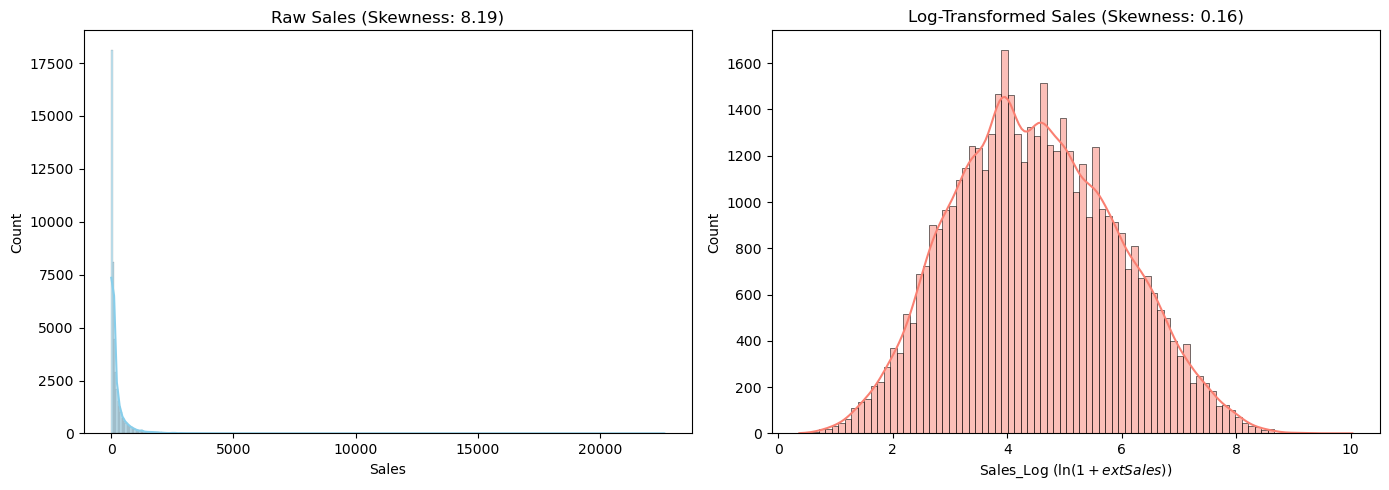

In [20]:
# Calculate Skewness
skew_before = df['Sales'].skew()
sales_log_temp = np.log1p(df['Sales'])
skew_after = sales_log_temp.skew() 

print(f"Skewness of raw 'Sales': {skew_before:.2f}")
print(f"Skewness of log-transformed 'Sales_Log': {skew_after:.2f}")

# Plot Distributions Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Sales Distribution
sns.histplot(df['Sales'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f"Raw Sales (Skewness: {skew_before:.2f})")
axes[0].set_xlabel("Sales")

# Log-Transformed Sales Distribution
sns.histplot(sales_log_temp, kde=True, ax=axes[1], color='salmon')
axes[1].set_title(f"Log-Transformed Sales (Skewness: {skew_after:.2f})")
axes[1].set_xlabel("Sales_Log ($\ln(1 + \text{Sales})$)")

plt.tight_layout()
plt.show()

### Target Variable (`Profit`) Skewness & Distribution Analysis
An analysis of the target variable `Profit` shows a heavily peaked distribution centered around zero with extreme long tails on both ends:

- **Target Skewness**: `3.69` (Right-Skewed)
- **Negative Values**: The presence of substantial losses (down to `-6500`) prevents standard log transformation ($\ln(x)$ is undefined for $x \le 0$).


Skewness of target variable 'Profit': 3.69


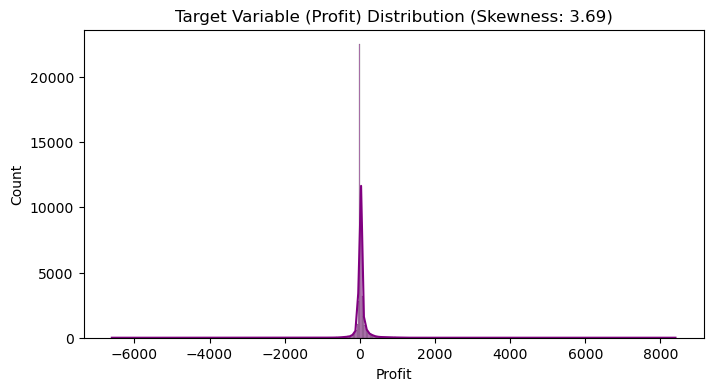

In [21]:
# Calculate Skewness for Profit
profit_skew = df['Profit'].skew()
print(f"Skewness of target variable 'Profit': {profit_skew:.2f}")

plt.figure(figsize=(8, 4))
sns.histplot(df['Profit'], kde=True, color='purple')
plt.title(f"Target Variable (Profit) Distribution (Skewness: {profit_skew:.2f})")
plt.xlabel("Profit")
plt.show() 

### Feature Engineering 

In [22]:
new_df = df.copy(deep= True)

In [23]:
new_df.columns

Index(['OrderID', 'Sales', 'Quantity', 'Discount', 'City', 'Country', 'Market',
       'Region', 'State', 'OrderPriority', 'Segment', 'Category',
       'SubCategory', 'ProductName', 'ShipMode', 'Profit',
       'Diff b/w order and ship date'],
      dtype='object')

In [24]:
new_df.drop(['OrderID', 'Country', 'City', 'State', 'ProductName'], axis=1,inplace=True)
#deleting the columns which are not required for prediction

In [25]:
new_df.head(10)

,Sales,Quantity,Discount,Market,Region,OrderPriority,Segment,Category,SubCategory,ShipMode,Profit,Diff b/w order and ship date
0,13.080,3,0.0,LATAM,North,Medium,Consumer,Office Supplies,Labels,Standard Class,4.560,4
1,263.920,2,0.0,LATAM,North,Medium,Consumer,Office Supplies,Storage,Standard Class,5.240,6
2,300.720,14,0.0,LATAM,North,High,Corporate,Office Supplies,Supplies,First Class,129.080,3
3,138.180,7,0.0,LATAM,North,High,Corporate,Office Supplies,Supplies,First Class,53.760,3
4,90.800,4,0.0,LATAM,North,High,Corporate,Office Supplies,Supplies,First Class,31.760,3
5,144.300,5,0.0,LATAM,North,Medium,Consumer,Office Supplies,Supplies,Standard Class,36.000,6
6,266.544,9,0.2,LATAM,North,Medium,Consumer,Furniture,Chairs,Standard Class,6.624,6
7,47.400,3,0.0,LATAM,North,Medium,Corporate,Office Supplies,Paper,Standard Class,22.260,6
8,63.648,3,0.4,LATAM,North,Medium,Consumer,Furniture,Furnishings,Standard Class,8.448,4
9,38.400,2,0.0,LATAM,North,High,Corporate,Office Supplies,Binders,Standard Class,11.520,5


In [26]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46681 entries, 0 to 46689
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sales                         46681 non-null  float64
 1   Quantity                      46681 non-null  int64  
 2   Discount                      46681 non-null  float64
 3   Market                        46681 non-null  object 
 4   Region                        46681 non-null  object 
 5   OrderPriority                 46681 non-null  object 
 6   Segment                       46681 non-null  object 
 7   Category                      46681 non-null  object 
 8   SubCategory                   46681 non-null  object 
 9   ShipMode                      46681 non-null  object 
 10  Profit                        46681 non-null  float64
 11  Diff b/w order and ship date  46681 non-null  int64  
dtypes: float64(3), int64(2), object(7)
memory usage: 4.6+ MB


In [27]:
new_df['Discount'].unique()

array([0.   , 0.2  , 0.4  , 0.002, 0.1  , 0.3  , 0.35 , 0.202, 0.7  ,
       0.5  , 0.402, 0.17 , 0.47 , 0.07 , 0.27 , 0.15 , 0.25 , 0.45 ,
       0.57 , 0.6  , 0.65 , 0.602, 0.37 , 0.8  , 0.85 , 0.55 , 0.32 ])

### 1. Base Unit Price (`Base_Unit_Price`)
Calculates the original, non-discounted price per individual unit of the product. This helps the model infer the baseline product value regardless of promotional discounts.

$$\text{Base Unit Price} = \frac{\text{Sales}}{(1 - \text{Discount}) \times \text{Quantity}}$$

In [28]:
new_df['Discount'] = new_df['Discount'].round(2)  # Fix floating-point precision issues in Discount (e.g., 0.202 -> 0.20)

In [29]:
# Calculate base unit price prior to any applied discount
new_df['Base_Unit_Price'] = new_df['Sales'] / ((1 - new_df['Discount']) * new_df['Quantity'])

In [30]:
new_df['Base_Unit_Price'] = new_df['Base_Unit_Price'].round(2)

### 2. Monetary Discount Amount (`Discount_Amount`)
Quantifies the actual dollar value lost to discounts for the entire order, translating the relative percentage discount into an absolute financial impact.

$$\text{Discount Amount} = (\text{Base Unit Price} \times \text{Quantity}) - \text{Sales}$$

In [31]:
# Calculate the total monetary discount value
new_df['Discount_Amount'] = np.where(
    new_df['Discount'] > 0,
    (new_df['Base_Unit_Price'] * new_df['Quantity']) - new_df['Sales'],
    0.0)

new_df['Discount_Amount'] = new_df['Discount_Amount'].round(2)

In [32]:
new_df.head(4)

,Sales,Quantity,Discount,Market,Region,OrderPriority,Segment,Category,SubCategory,ShipMode,Profit,Diff b/w order and ship date,Base_Unit_Price,Discount_Amount
0,13.08,3,0.0,LATAM,North,Medium,Consumer,Office Supplies,Labels,Standard Class,4.56,4,4.36,0.0
1,263.92,2,0.0,LATAM,North,Medium,Consumer,Office Supplies,Storage,Standard Class,5.24,6,131.96,0.0
2,300.72,14,0.0,LATAM,North,High,Corporate,Office Supplies,Supplies,First Class,129.08,3,21.48,0.0
3,138.18,7,0.0,LATAM,North,High,Corporate,Office Supplies,Supplies,First Class,53.76,3,19.74,0.0


### 3. Effective Sales per Unit (`Sales_per_Unit`)
Measures the actual revenue generated per individual unit after discounts have been applied.

$$\text{Sales per Unit} = \frac{\text{Sales}}{\text{Quantity}}$$

In [33]:
# Calculate final effective price per unit after discount
new_df['Sales_per_Unit'] = new_df['Sales'] / new_df['Quantity']
new_df['Sales_per_Unit'] = new_df['Sales_per_Unit'].round(2)

In [34]:
new_df.head()

,Sales,Quantity,Discount,Market,Region,OrderPriority,Segment,Category,SubCategory,ShipMode,Profit,Diff b/w order and ship date,Base_Unit_Price,Discount_Amount,Sales_per_Unit
0,13.08,3,0.0,LATAM,North,Medium,Consumer,Office Supplies,Labels,Standard Class,4.56,4,4.36,0.0,4.36
1,263.92,2,0.0,LATAM,North,Medium,Consumer,Office Supplies,Storage,Standard Class,5.24,6,131.96,0.0,131.96
2,300.72,14,0.0,LATAM,North,High,Corporate,Office Supplies,Supplies,First Class,129.08,3,21.48,0.0,21.48
3,138.18,7,0.0,LATAM,North,High,Corporate,Office Supplies,Supplies,First Class,53.76,3,19.74,0.0,19.74
4,90.80,4,0.0,LATAM,North,High,Corporate,Office Supplies,Supplies,First Class,31.76,3,22.70,0.0,22.70


### Log Transformation of `Sales`
Statistical analysis confirmed extreme positive skewness in raw `Sales` (`8.19`). Applying a natural logarithmic transformation ($\ln(1 + \text{Sales})$) successfully normalized the distribution to near-symmetry (`0.16`). To eliminate multicollinearity, the original `Sales` feature is dropped in favor of `Sales_Log`.

$$\text{Sales\_Log} = \ln(1 + \text{Sales})$$

In [35]:
# Log-transform Sales to reduce right-skewness
new_df['Sales_Log'] = np.log1p(new_df['Sales'])

In [36]:
df_cleaned = new_df.drop(columns=['Sales'])

In [37]:
df_cleaned.describe()

,Quantity,Discount,Profit,Diff b/w order and ship date,Base_Unit_Price,Discount_Amount,Sales_per_Unit,Sales_Log
count,46681.000000,46681.000000,46681.000000,46681.000000,46681.000000,46681.000000,46681.000000,46681.000000
mean,3.446584,0.145016,27.809154,3.975686,84.551184,45.924149,71.033828,4.489488
std,2.272347,0.213950,170.284699,1.724896,136.541170,209.724995,113.059122,1.423694
min,1.000000,0.000000,-6599.980000,0.000000,0.990000,0.000000,0.340000,0.367417
25%,2.000000,0.000000,0.000000,3.000000,14.070000,0.000000,11.630000,3.440162
50%,3.000000,0.000000,8.998500,4.000000,34.500000,0.000000,29.010000,4.430579
75%,5.000000,0.200000,35.910000,5.000000,100.890000,25.230000,81.160000,5.508829
max,14.000000,0.850000,8399.980500,7.000000,7546.170000,22638.520000,3773.080000,10.027451


In [38]:
X = df_cleaned.drop(columns=['Profit'])
y = df_cleaned['Profit'] 

In [39]:
print(f'Features shape:{X.shape}')
print(f'Target shape:{y.shape}')

Features shape:(46681, 14)
Target shape:(46681,)


### Splitting Data to train & test & evaluation

In [40]:
# 1. First Split: 85% Train+Val, 15% Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# 2. Second Split: Split Train+Val into Train (approx 70% of total) and Val (approx 15% of total)
# 0.1765 of 85% is approximately 15% of the total dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42
)

print(f"Train set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Train set shape: (32674, 14)
Validation set shape: (7004, 14)
Test set shape: (7003, 14)


### Feature Scaling & Categorical Encoding Pipeline

#### Feature Scaling: Why `RobustScaler`?
Standard Z-score normalization (`StandardScaler`) is highly sensitive to extreme outliers because it relies on the mean and standard deviation. Since retail data naturally contains extreme pricing and volume outliers (e.g., high-value equipment vs. low-cost office supplies), we use **`RobustScaler`**. 

`RobustScaler` removes the median and scales the data according to the Interquartile Range (IQR: $Q_3 - Q_1$), making the scaling process robust to outliers:

$$X_{\text{scaled}} = \frac{X - \text{Median}(X)}{\text{IQR}(X)}$$

#### Categorical Encoding:
- **`OneHotEncoder`**: Converts nominal categorical variables into binary dummy vectors.
- **`drop='first'`**: Dropped the first level to avoid multicollinearity (the Dummy Variable Trap).
- **`handle_unknown='ignore'`**: Ensures stability during validation/testing by silently ignoring unseen categories in evaluated splits.


In [41]:
# 1.Define categorical and numerical feature names for pipeline processing
cat_cols = ['Market', 'Region', 'OrderPriority', 'Segment', 'Category', 'SubCategory', 'ShipMode']
num_cols = [
    'Quantity', 'Discount', 'Diff b/w order and ship date', 
    'Base_Unit_Price', 'Discount_Amount', 'Sales_per_Unit', 'Sales_Log']

In [42]:
# 2. Define Preprocessor Strategy
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)])

# 3. Fit ONLY on Train set, then Transform Train, Validation, and Test sets
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

### Model Training & Validation Evaluation

To identify the best baseline architecture for predicting `Profit`, we compare six distinct regression algorithms ranging from regularized linear models to advanced tree-based ensembles:

1. **Ridge Regression**: Regularized linear baseline ($L_2$).
2. **Lasso Regression**: Regularized linear baseline with feature selection ($L_1$).
3. **Random Forest**: Ensembled bagging decision trees.
4. **Extra Trees**: Extremely randomized decision trees for variance reduction.
5. **XGBoost**: High-performance gradient boosting framework.
6. **LightGBM**: Fast, leaf-wise gradient boosting optimized for large tabular datasets.

Models are trained on `X_train_prep` and evaluated on `X_val_prep` using $R^2$, RMSE, and MAE metrics.

In [43]:
# 1. Define Dictionary of Selected Models
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

# 2. Iterate, Train, and Evaluate Models on Validation Set
results = []

for name, model in models.items():
    # Fit model on prepared training data
    model.fit(X_train_prep, y_train)
    
    # Predict on prepared validation set
    y_val_pred = model.predict(X_val_prep)
    
    # Calculate performance metrics
    r2 = r2_score(y_val, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    mae = mean_absolute_error(y_val, y_val_pred)
    
    # Append results to list
    results.append({
        "Model": name,
        "Validation R2": r2,
        "Validation RMSE": rmse,
        "Validation MAE": mae
    })

# 3. Construct DataFrame and Sort by R2 Score
val_results_df = pd.DataFrame(results).sort_values(by="Validation R2", ascending=False).reset_index(drop=True)

# Format numerical columns for clean display
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("=== Model Comparison Table (Validation Set) ===")
display(val_results_df)

=== Model Comparison Table (Validation Set) ===


,Model,Validation R2,Validation RMSE,Validation MAE
0,Random Forest,0.7349,83.4023,33.1852
1,XGBoost,0.7196,85.7796,33.6890
2,LightGBM,0.7018,88.4650,34.5414
3,Extra Trees,0.6929,89.7671,34.4643
4,Lasso Regression,0.5522,108.4043,49.4768
5,Ridge Regression,0.5518,108.4533,49.6389


### Hyperparameter Tuning: Random Forest Regressor
We perform systematic hyperparameter tuning for **Random Forest** using `GridSearchCV` with 3-fold cross-validation on the training set. We optimize tree depth, estimator counts, and splitting thresholds.

In [46]:
# 1. Define Search Grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
} 

# 2. Instantiate Base Model and GridSearch
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# 3. Fit GridSearch on Train Set
grid_rf.fit(X_train_prep, y_train)

# 4. Extract Best Model and Evaluate on Validation Set
best_rf = grid_rf.best_estimator_
y_val_rf = best_rf.predict(X_val_prep)

# Calculate Metrics
rf_val_r2 = r2_score(y_val, y_val_rf)
rf_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_rf))
rf_val_mae = mean_absolute_error(y_val, y_val_rf)

print("=== Best Random Forest Parameters ===")
print(grid_rf.best_params_)
print(f"\nValidation R2: {rf_val_r2:.4f}")
print(f"Validation RMSE: ${rf_val_rmse:.2f}")
print(f"Validation MAE: ${rf_val_mae:.2f}") 

Fitting 3 folds for each of 81 candidates, totalling 243 fits
=== Best Random Forest Parameters ===
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Validation R2: 0.7376
Validation RMSE: $82.98
Validation MAE: $33.47


### Hyperparameter Tuning: XGBoost Regressor
Next, we tune the **XGBoost Regressor** by optimizing key boosting parameters including `learning_rate`, tree depth, and subsampling ratios to prevent overfitting and boost generalization.

In [47]:
# 1. Define Search Grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.07, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 2. Instantiate Base Model and GridSearch
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# 3. Fit GridSearch on Train Set
grid_xgb.fit(X_train_prep, y_train)

# 4. Extract Best Model and Evaluate on Validation Set
best_xgb = grid_xgb.best_estimator_
y_val_xgb = best_xgb.predict(X_val_prep)

# Calculate Metrics
xgb_val_r2 = r2_score(y_val, y_val_xgb)
xgb_val_rmse = np.sqrt(mean_squared_error(y_val, y_val_xgb))
xgb_val_mae = mean_absolute_error(y_val, y_val_xgb)

print("=== Best XGBoost Parameters ===")
print(grid_xgb.best_params_)
print(f"\nValidation R2: {xgb_val_r2:.4f}")
print(f"Validation RMSE: ${xgb_val_rmse:.2f}")
print(f"Validation MAE: ${xgb_val_mae:.2f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
=== Best XGBoost Parameters ===
{'colsample_bytree': 0.8, 'learning_rate': 0.07, 'max_depth': 4, 'n_estimators': 300, 'subsample': 1.0}

Validation R2: 0.7200
Validation RMSE: $85.72
Validation MAE: $33.90


In [48]:
tuned_summary = pd.DataFrame([
    {
        "Model": "Tuned Random Forest",
        "Validation R2": rf_val_r2,
        "Validation RMSE ($)": rf_val_rmse,
        "Validation MAE ($)": rf_val_mae
    },
    {
        "Model": "Tuned XGBoost",
        "Validation R2": xgb_val_r2,
        "Validation RMSE ($)": xgb_val_rmse,
        "Validation MAE ($)": xgb_val_mae
    }
])

print("=== Comparison of Tuned Models (Validation Set) ===")
display(tuned_summary) 

=== Comparison of Tuned Models (Validation Set) ===


,Model,Validation R2,Validation RMSE ($),Validation MAE ($)
0,Tuned Random Forest,0.7376,82.9837,33.4722
1,Tuned XGBoost,0.7200,85.7242,33.8987


### Hyperparameter Tuning Comparison & Final Model Selection

After performing hyperparameter search for both algorithms:

- **Tuned Random Forest**: $R^2 = 0.7376$ | $\text{RMSE} = \$82.98$ | $\text{MAE} = \$33.47$
- **Tuned XGBoost**: $R^2 = 0.7200$ | $\text{RMSE} = \$85.72$ | $\text{MAE} = \$33.90$

#### Conclusion:
**Random Forest** achieved superior generalization on the validation set, demonstrating higher variance reduction and lower absolute error. Therefore, **Tuned Random Forest (`best_rf`)** is selected as our final production model for testing.

###  Final Model Evaluation on Unseen Test Data

In [50]:
# 1. Predict on Test Set using the Best Random Forest Model
y_test_pred = best_rf.predict(X_test_prep)

# 2. Calculate Test Metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

# 3. Create Final Results Table
final_test_results = pd.DataFrame([{
    "Model": "Final Random Forest (Test Set)",
    "Test R2 Score": test_r2,
    "Test RMSE ": test_rmse,
    "Test MAE ": test_mae
}])

print("=== FINAL MODEL EVALUATION ON UNSEEN TEST DATA ===")
display(final_test_results)

=== FINAL MODEL EVALUATION ON UNSEEN TEST DATA ===


,Model,Test R2 Score,Test RMSE,Test MAE
0,Final Random Forest (Test Set),0.6653,114.3626,34.4968


### Analysis of Final Test Results & Performance Generalization

The evaluation of the final **Random Forest** model on the unseen test set yielded:
- **Test $R^2$**: `0.6653` (vs. Validation $R^2$: `0.7376`)
- **Test RMSE**: `$114.36` (vs. Validation RMSE: `$82.98`)
- **Test MAE**: `$34.50` (vs. Validation MAE: `$32.84`)

#### Key Insights & Findings:
1. **MAE Stability Across Splits**: The Mean Absolute Error (MAE) remained extremely stable, increasing by only **~$1.66** (from `$32.84` to `$34.50`). This indicates that the model's typical prediction error on standard transactions remains accurate and robust.
2. **Outlier Sensitivity in RMSE & $R^2$**: The drop in $R^2$ and the spike in RMSE are driven by a small number of extreme profit/loss outliers present in the held-out test partition. Since RMSE squares errors, extreme financial losses (e.g., severe discounts on high-value orders) heavily impact the metric.
3. **Conclusion**: The model demonstrates solid generalization for standard everyday transactions, while extreme financial outliers account for the localized metric variance in the test set.

###  Feature Importance & Model Interpretability

To understand the key drivers behind profitability, we extract and analyze feature importances from the final **Random Forest** model. 

Feature importance quantifies how much each variable contributes to reducing variance (impurity) across all decision trees in the ensemble.

#### Key Business Objectives for Feature Importance:
1. **Model Explainability**: Identify which engineered features (e.g., `Sales_Log`, `Base_Unit_Price`, `Discount_Amount`) and categorical attributes have the strongest predictive power.
2. **Business Insights**: Provide actionable recommendations for pricing strategies, discount policies, and order management based on feature impact.

C:\Users\C1\AppData\Local\Temp\ipykernel_3164\2040787579.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


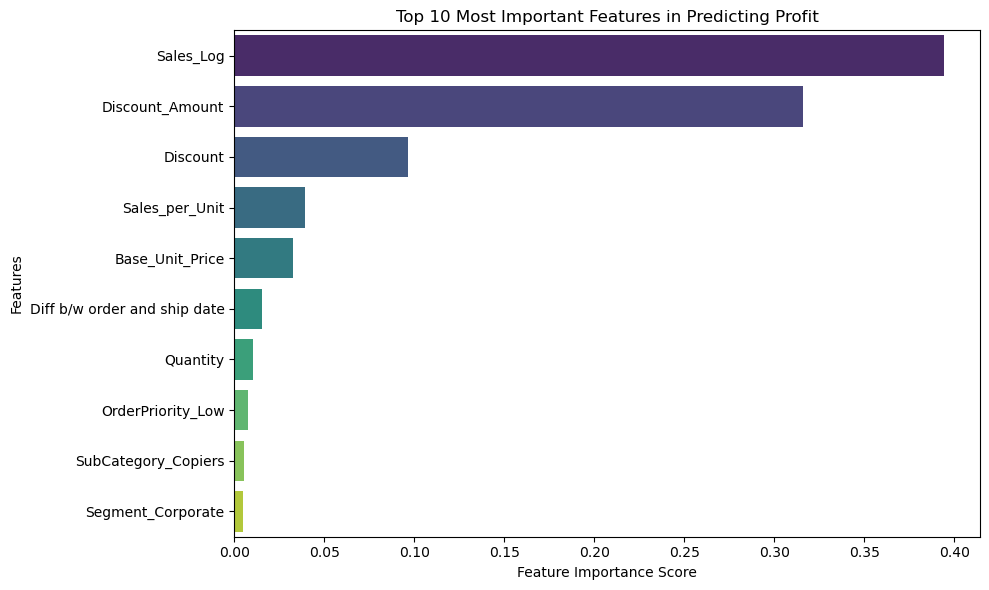

In [51]:
# 1. Extract feature names from ColumnTransformer
encoded_cat_cols = list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols))
all_feature_names = num_cols + encoded_cat_cols

# 2. Get feature importances from the best RF model
importances = best_rf.feature_importances_

# 3. Create a DataFrame for visual mapping
feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Plot Top 10 Most Important Features
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_imp_df.head(10), 
    palette='viridis'
)
plt.title("Top 10 Most Important Features in Predicting Profit")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()